In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import sys

from lerobot_so_arm.config import get_path
from lerobot_so_arm.utils.data_loading import load_traj_from_HDF5, check_traj_format
from lerobot_so_arm.utils.visualization import visualize_so_trajectory
from lerobot_so_arm.utils.transform import DatasetTransformer

vjepa_root = get_path('vjepa_root')
sys.path.append(vjepa_root)

#SOURCE_PATH = "/teamspace/studios/this_studio/test_dataset/source/episodes/smanni+train_so100_all-episode_001"
SOURCE_PATH = get_path('datasets') + "/source/episodes/smanni+train_so100_all-episode_001"
OUTPUT_PATH = get_path('datasets') + "/output/episodes/smanni+train_so100_all-episode_001"

# Initialize dataset transformer
transformer = DatasetTransformer()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


****** Checking trajectory format ******
  Path: trajectory.h5
  Joint states [observation/state]: (598, 6)
  Timestamps [metadata/timestamp]: (598,)
  Actions [action/data]: (598, 6)
Using joint states with shape: (598, 6)
Created timestamps array with shape: (598,)


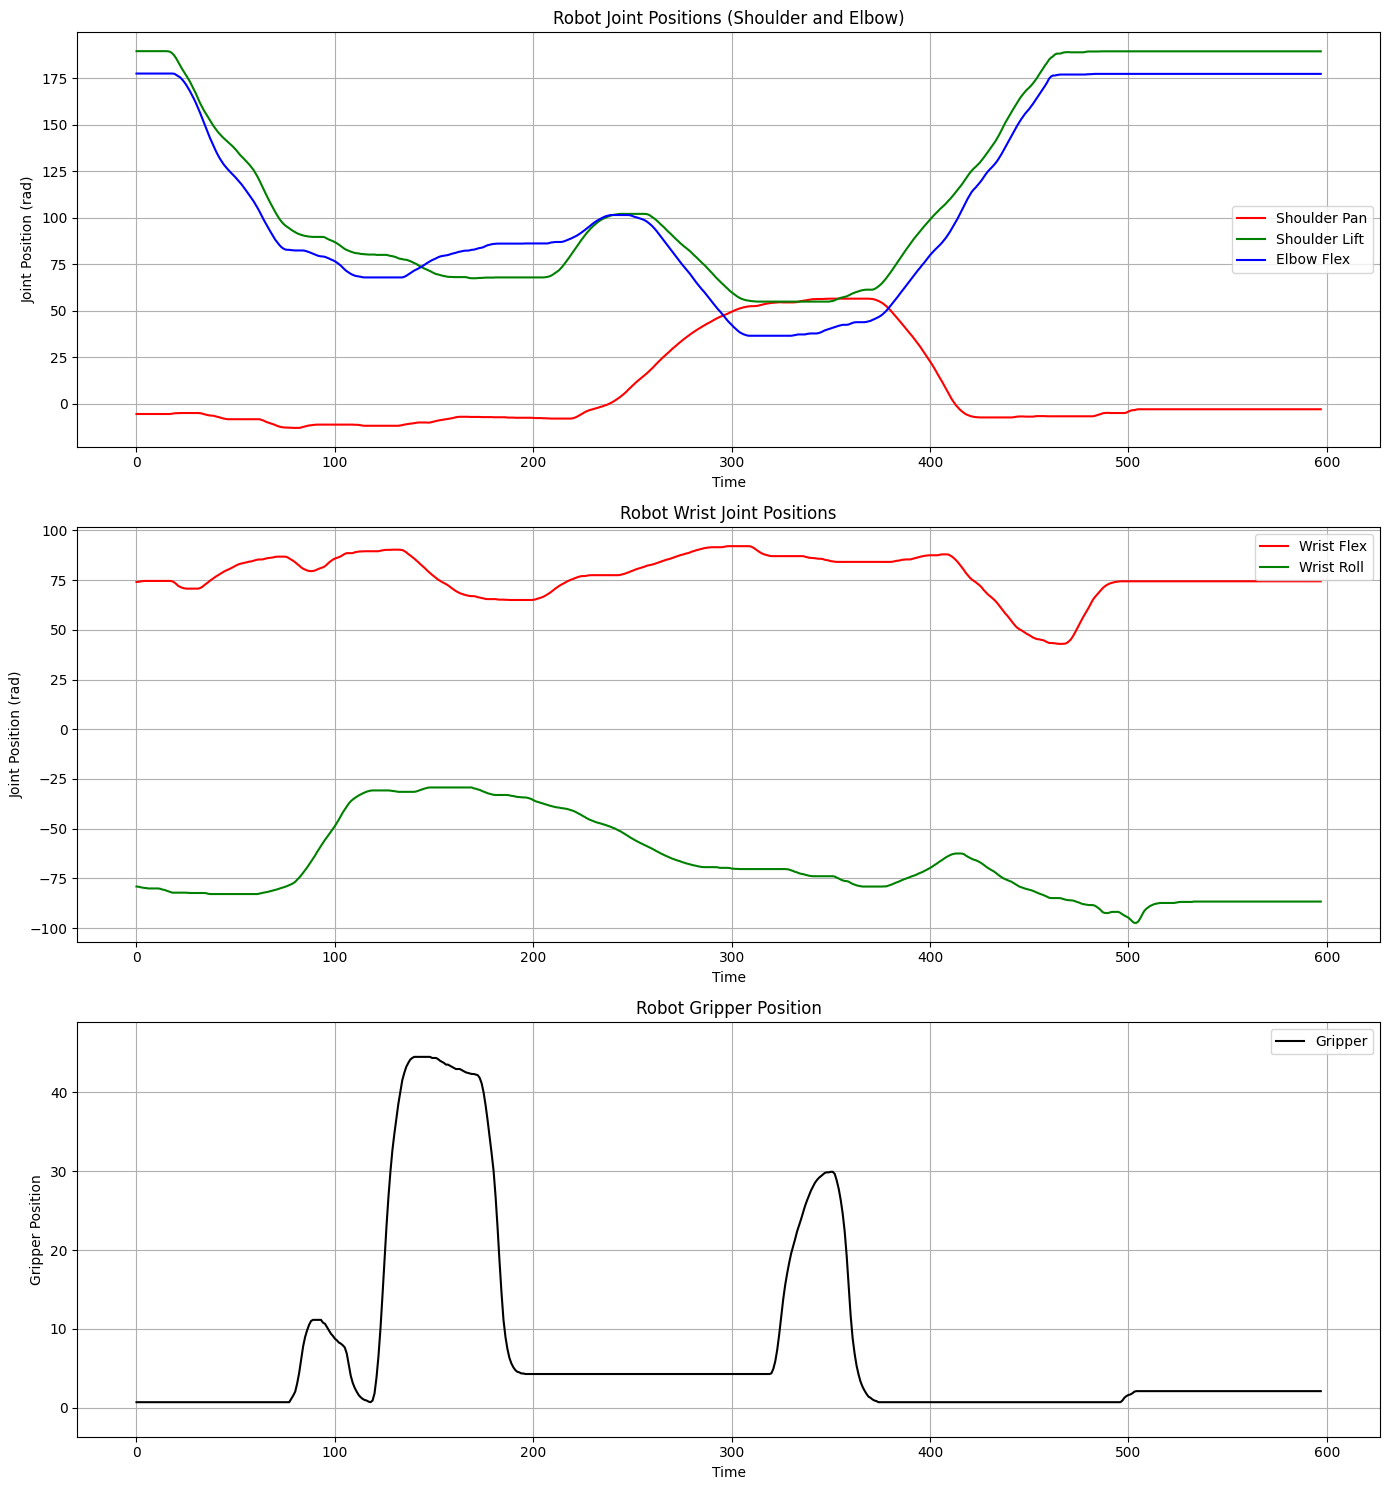


Trajectory Statistics:
Total duration: 598 timesteps
Joint angle ranges:
  Shoulder Pan: [-13.0957, 56.4258] rad
  Shoulder Lift: [54.8438, 189.5801] rad
  Elbow Flex: [36.4746, 177.5391] rad
  Wrist Flex: [42.9785, 92.1094] rad
  Wrist Roll: [-97.3828, -29.2676] rad
  Gripper: [0.7008, 44.4990]

Note: To visualize the robot trajectory in 3D space, we would need to apply
forward kinematics to convert joint angles to end-effector positions.
You can use the utils.kinematics.RobotKinematics class for this purpose.

Original joint states preview (first 5 rows):
   shoulder_pan  shoulder_lift  elbow_flex  wrist_flex  wrist_roll  gripper_position
0        -5.625     189.580078  177.539062   74.091797  -79.101562          0.700771
1        -5.625     189.580078  177.539062   74.179688  -79.189453          0.700771
2        -5.625     189.580078  177.539062   74.355469  -79.453125          0.700771
3        -5.625     189.580078  177.539062   74.531250  -79.628906          0.700771
4        -

In [2]:
# Load and check original trajectory data
source_trajectory_path = os.path.join(SOURCE_PATH, 'trajectory.h5')
trajectory_data = load_traj_from_HDF5(source_trajectory_path)

# Check format and show crisp info
check_traj_format(trajectory_data, source_trajectory_path)

# Visualize original joint states
joint_states = trajectory_data['joint_states']
visualize_so_trajectory(joint_states, timestamps=None, title="Original SO Robot Trajectory")

# Display joint states as DataFrame
joint_states_df = pd.DataFrame(
    joint_states,
    columns=['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper_position']
)
print("\nOriginal joint states preview (first 5 rows):")
print(joint_states_df.head())


In [4]:
# Transform episode

transformer.transform_episode(SOURCE_PATH, OUTPUT_PATH)
print(f"========== Transformed episode\n\t{SOURCE_PATH}\n----->\t{OUTPUT_PATH}")
       
# Load and check transformed data
output_trajectory_path = os.path.join(OUTPUT_PATH, 'trajectory.h5')
transformed_data = load_traj_from_HDF5(output_trajectory_path)

print("\nTransformed data format:")
check_traj_format(transformed_data, output_trajectory_path)

Auto-detected calibration: so_old_calibration
========== Transformed episode
	/Users/michelmeyer/.local/dev/test_dataset/source/episodes/smanni+train_so100_all-episode_001
----->	/Users/michelmeyer/.local/dev/test_dataset/output/episodes/smanni+train_so100_all-episode_001

Transformed data format:
****** Checking trajectory format ******
  Path: trajectory.h5
  Joint states [observation/state]: (598, 6)
  Cartesian positions [observation/robot_state/cartesian_position]: (598, 6)
  Gripper positions [observation/robot_state/gripper_position]: (598, 1)
  Timestamps [metadata/timestamp]: (598,)
